# Analise Exploratoria - Camada SILVER
## E-commerce Brasileiro (Olist)

---

### Arquitetura de Dados - Camada SILVER

**Contexto:**  
Esta analise opera sobre a **Camada SILVER** da arquitetura medalhao, onde os dados foram:
- Integrados a partir das entidades de pedidos, itens, clientes, pagamentos e produtos
- Padronizados para consumo analitico (`fact_sales_olist`)
- Validados quanto a qualidade, consistencia e duplicidade de chave
- Preparados para gerar indicadores da camada Gold

**Fonte de Dados:**  
`fact_sales_olist.parquet` (preferencial) ou `fact_sales_olist.csv`

---

### Objetivos da Analise

1. Validar qualidade e integridade da tabela consolidada
2. Confirmar consistencia de chave de negocio (`order_id + order_item_id`)
3. Explorar comportamento de vendas, status e categorias
4. Verificar distribuicoes e outliers de ticket
5. Consolidar prontidao da Silver para alimentar a camada Gold

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

SILVER_DIR = Path(".")
parquet_path = SILVER_DIR / "fact_sales_olist.parquet"
csv_path = SILVER_DIR / "fact_sales_olist.csv"

fact_sales = None
source_used = None

if parquet_path.exists():
    try:
        fact_sales = pd.read_parquet(parquet_path)
        source_used = parquet_path.name
    except Exception as parquet_err:
        print(f"Falha ao ler Parquet ({parquet_err}). Tentando CSV...")

if fact_sales is None and csv_path.exists():
    fact_sales = pd.read_csv(csv_path, encoding="utf-8")
    source_used = csv_path.name

if fact_sales is None:
    raise FileNotFoundError("Nenhum arquivo fact_sales_olist valido encontrado em Data Layer/silver")

print(f"Fonte carregada: {source_used}")
print(f"Dimensoes: {fact_sales.shape[0]:,} linhas x {fact_sales.shape[1]} colunas")

print("\nHead:")
display(fact_sales.head())

print("\nInfo:")
fact_sales.info()

Fonte carregada: fact_sales.parquet
Dimensoes: 112,650 linhas x 51 colunas

Head:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_geolocation_zip_code_prefix,customer_geolocation_lat,customer_geolocation_lng,customer_geolocation_city,customer_geolocation_state,seller_zip_code_prefix,seller_city,seller_state,seller_geolocation_zip_code_prefix,seller_geolocation_lat,seller_geolocation_lng,seller_geolocation_city,seller_geolocation_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,total_payment_value,mean_payment_value,n_payment_events,max_installments,main_payment_type,review_score_mean,review_score_min,review_score_max,n_reviews,has_comment,last_review_answer_at
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,28013.0,-21.763186,-41.310265,campos dos goytacazes,RJ,27277,volta redonda,SP,27277.0,-22.497188,-44.127324,volta redonda,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,72.19,72.19,1.0,2.0,credit_card,5.0,5.0,5.0,1.0,True,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,15775.0,-20.222506,-50.898951,santa fe do sul,SP,3471,sao paulo,SP,3471.0,-23.565754,-46.519097,sao paulo,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,259.83,259.83,1.0,3.0,credit_card,4.0,4.0,4.0,1.0,False,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,35661.0,-19.869998,-44.593059,para de minas,MG,37564,borda da mata,MG,37564.0,-22.262802,-46.170735,borda da mata,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,216.87,216.87,1.0,5.0,credit_card,5.0,5.0,5.0,1.0,True,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,12952.0,-23.105968,-46.590277,atibaia,SP,14403,franca,SP,14403.0,-20.553651,-47.387145,franca,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,25.78,25.78,1.0,2.0,credit_card,4.0,4.0,4.0,1.0,False,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,13226.0,-23.243402,-46.827614,varzea paulista,SP,87900,loanda,PR,87900.0,-22.929583,-53.135750,loanda,PR,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,218.04,218.04,1.0,3.0,credit_card,5.0,5.0,5.0,1.0,True,2017-03-03 10:54:59



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 51 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   order_id                              112650 non-null  object        
 1   order_item_id                         112650 non-null  int64         
 2   product_id                            112650 non-null  object        
 3   seller_id                             112650 non-null  object        
 4   shipping_limit_date                   112650 non-null  object        
 5   price                                 112650 non-null  float64       
 6   freight_value                         112650 non-null  float64       
 7   customer_id                           112650 non-null  object        
 8   order_status                          112650 non-null  object        
 9   order_purchase_timestamp              112650 non-nul

### Dicionario de Dados — fact_sales

Mapeamento completo de colunas, tipos e origem de cada atributo da tabela consolidada.

In [6]:
origem_map = {
    "order_id": "orders",
    "order_item_id": "order_items",
    "product_id": "order_items / products",
    "seller_id": "order_items / sellers",
    "shipping_limit_date": "order_items",
    "price": "order_items",
    "freight_value": "order_items",
    "customer_id": "orders",
    "order_status": "orders",
    "order_purchase_timestamp": "orders",
    "order_approved_at": "orders",
    "order_delivered_carrier_date": "orders",
    "order_delivered_customer_date": "orders",
    "order_estimated_delivery_date": "orders",
    "customer_unique_id": "customers",
    "customer_zip_code_prefix": "customers",
    "customer_city": "customers",
    "customer_state": "customers",
    "customer_geolocation_lat": "geolocation",
    "customer_geolocation_lng": "geolocation",
    "seller_zip_code_prefix": "sellers",
    "seller_city": "sellers",
    "seller_state": "sellers",
    "seller_geolocation_lat": "geolocation",
    "seller_geolocation_lng": "geolocation",
    "product_category_name": "products",
    "product_category_name_english": "category_translation",
    "product_weight_g": "products",
    "total_payment_value": "payments (agregado)",
    "max_installments": "payments (agregado)",
    "main_payment_type": "payments (agregado)",
    "review_score_mean": "reviews (agregado)",
    "has_comment": "reviews (agregado)",
}

dict_df = pd.DataFrame({
    "Coluna": fact_sales.columns,
    "Tipo": fact_sales.dtypes.astype(str).values,
    "Nulos": fact_sales.isnull().sum().values,
    "Nulos_%": (fact_sales.isnull().mean() * 100).round(2).values,
    "Origem": [origem_map.get(c, "silver (calculado)") for c in fact_sales.columns],
})

print(f"Dicionario da fact_sales  —  {len(dict_df)} colunas")
display(dict_df)

Dicionario da fact_sales  —  51 colunas


,Coluna,Tipo,Nulos,Nulos_%,Origem
0,order_id,object,0,0.00,orders
1,order_item_id,int64,0,0.00,order_items
2,product_id,object,0,0.00,order_items / products
3,seller_id,object,0,0.00,order_items / sellers
4,shipping_limit_date,object,0,0.00,order_items
5,price,float64,0,0.00,order_items
6,freight_value,float64,0,0.00,order_items
7,customer_id,object,0,0.00,orders
8,order_status,object,0,0.00,orders
9,order_purchase_timestamp,datetime64[ns],0,0.00,orders


## Analises Exploratorias de Validacao

Analises para validar consistencia da Silver:
- Distribuicao de status de pedido
- Evolucao mensal de receita
- Top categorias por receita
- Distribuicao de ticket por item

### Contexto de Negocio

As analises abaixo verificam se os padroes da Silver fazem sentido para operacao de e-commerce.

### 2.1 Status dos Pedidos
Distribuicao dos status para validar integridade operacional do pipeline.

### 2.2 Receita Mensal
Evolucao temporal da receita para confirmar consistencia dos dados ao longo do tempo.

**Observacao metodologica:** a queda acentuada em `2018-09` esta associada a **mes incompleto** no recorte temporal do dataset (coleta encerrada no inicio de setembro). Portanto, o valor mensal desse periodo nao deve ser comparado diretamente com meses completos.

Como boa pratica analitica, para comparacao temporal justa recomenda-se:
- usar receita media diaria por mes, ou
- excluir meses incompletos das analises de tendencia.

### 2.3 Top Categorias por Receita
Ranking das categorias para verificar se o mix de produtos esta coerente.

### 2.4 Ticket Medio por Item
Distribuicao de preco para identificar outliers e validar a faixa de valores esperada.

In [2]:
print("Estatisticas descritivas (numericas):")
display(fact_sales.describe(include=[np.number]).T)

print("\nEstatisticas descritivas (categoricas):")
display(fact_sales.describe(include=["object", "category"]).T)

nulls = fact_sales.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(fact_sales) * 100).round(2)
nulls_df = pd.DataFrame({"null_count": nulls, "null_pct": nulls_pct})

print("\nTop colunas com nulos:")
display(nulls_df[nulls_df["null_count"] > 0].head(20))

key_dups = fact_sales.duplicated(subset=["order_id", "order_item_id"]).sum()
row_dups = fact_sales.duplicated().sum()

print(f"Duplicidades da chave (order_id + order_item_id): {key_dups:,}")
print(f"Duplicidades de linha completa: {row_dups:,}")

if key_dups == 0:
    print("Status da chave: OK")
else:
    print("Status da chave: ALERTA")

Estatisticas descritivas (numericas):


,count,mean,std,min,25%,50%,75%,max
order_item_id,112650.0,1.197834,0.705124,1.0,1.0,1.0,1.0,21.0
price,112650.0,120.653739,183.633928,0.85,39.9,74.99,134.9,6735.0
freight_value,112650.0,19.99032,15.806405,0.0,13.08,16.26,21.15,409.68
customer_zip_code_prefix,112650.0,35119.30909,29866.120801,1003.0,11310.0,24340.0,59028.75,99990.0
customer_geolocation_zip_code_prefix,112348.0,35042.482652,29853.323545,1003.0,11250.0,24240.0,58430.25,99990.0
customer_geolocation_lat,112348.0,-21.233212,5.570737,-33.68989,-23.591055,-22.929151,-20.175876,42.184003
customer_geolocation_lng,112348.0,-46.201934,4.038345,-72.668821,-48.109939,-46.634221,-43.635549,-8.723762
seller_zip_code_prefix,112650.0,24439.170431,27596.030909,1001.0,6429.0,13568.0,27930.0,99730.0
seller_geolocation_zip_code_prefix,112397.0,24435.840191,27593.085486,1001.0,6429.0,13568.0,27345.0,99730.0
seller_geolocation_lat,112397.0,-22.797779,2.697401,-32.075303,-23.608066,-23.424361,-21.757225,-2.503158



Estatisticas descritivas (categoricas):


,count,unique,top,freq
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527
seller_id,112650,3095,6560211a19b47992c3666cc44a7e94c0,2033
shipping_limit_date,112650,93318,2018-03-01 02:50:48,21
customer_id,112650,98666,fc3d1daec319d62d49bfb5e1f83123e9,21
order_status,112650,7,delivered,110197
customer_unique_id,112650,95420,c8460e4251689ba205045f3ea17884a1,24
customer_city,112650,4110,sao paulo,17808
customer_state,112650,27,SP,47449
customer_geolocation_city,112348,4049,sao paulo,17795



Top colunas com nulos:


,null_count,null_pct
order_delivered_customer_date,2454,2.18
order_delivered_carrier_date,1194,1.06
has_comment,942,0.84
review_score_mean,942,0.84
review_score_min,942,0.84
review_score_max,942,0.84
n_reviews,942,0.84
last_review_answer_at,942,0.84
customer_geolocation_lat,302,0.27
customer_geolocation_lng,302,0.27


Duplicidades da chave (order_id + order_item_id): 0
Duplicidades de linha completa: 0
Status da chave: OK


## Dashboard de Metricas — fact_sales

Resumo executivo dos principais indicadores da tabela Silver antes das analises graficas.

In [7]:
print("=" * 60)
print("  RESUMO DA FACT_SALES — CAMADA SILVER")
print("=" * 60)
print(f"  Pedidos.............: {fact_sales['order_id'].nunique():,}")
print(f"  Itens vendidos......: {len(fact_sales):,}")
print(f"  Clientes............: {fact_sales['customer_unique_id'].nunique():,}")
print(f"  Produtos............: {fact_sales['product_id'].nunique():,}")
print(f"  Vendedores..........: {fact_sales['seller_id'].nunique():,}")
print(f"  Categorias..........: {fact_sales['product_category_name_english'].nunique():,}")
print(f"  Estados (clientes)..: {fact_sales['customer_state'].nunique():,}")
print(f"  Receita total.......: R$ {fact_sales['price'].sum():,.2f}")
print(f"  Ticket medio/item...: R$ {fact_sales['price'].mean():,.2f}")
print(f"  Nota media reviews..: {fact_sales['review_score_mean'].mean():.2f} / 5.0")
print("=" * 60)

  RESUMO DA FACT_SALES — CAMADA SILVER
  Pedidos.............: 98,666
  Itens vendidos......: 112,650
  Clientes............: 95,420
  Produtos............: 32,951
  Vendedores..........: 3,095
  Categorias..........: 74
  Estados (clientes)..: 27
  Receita total.......: R$ 13,591,643.70
  Ticket medio/item...: R$ 120.65
  Nota media reviews..: 4.03 / 5.0


## 2. Analises Exploratorias de Validacao

### Contexto de Negocio

As analises abaixo verificam se os padroes da Silver fazem sentido para operacao de e-commerce.

### 2.1 Status dos Pedidos
Distribuicao dos status para validar integridade operacional do pipeline.

### 2.2 Receita Mensal
Evolucao temporal da receita para confirmar consistencia dos dados ao longo do tempo.

### 2.3 Top Categorias por Receita
Ranking das categorias para verificar se o mix de produtos esta coerente.

### 2.4 Ticket Medio por Item
Distribuicao de preco para identificar outliers e validar a faixa de valores esperada.

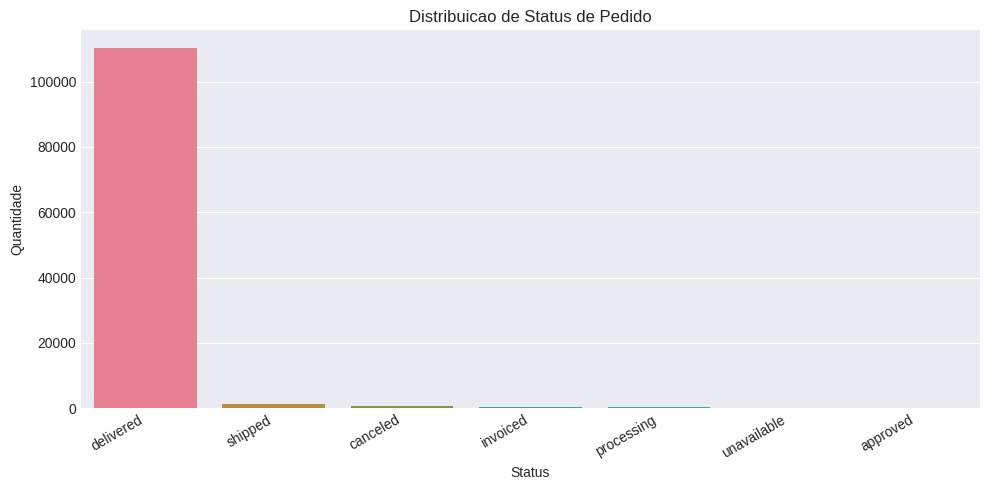

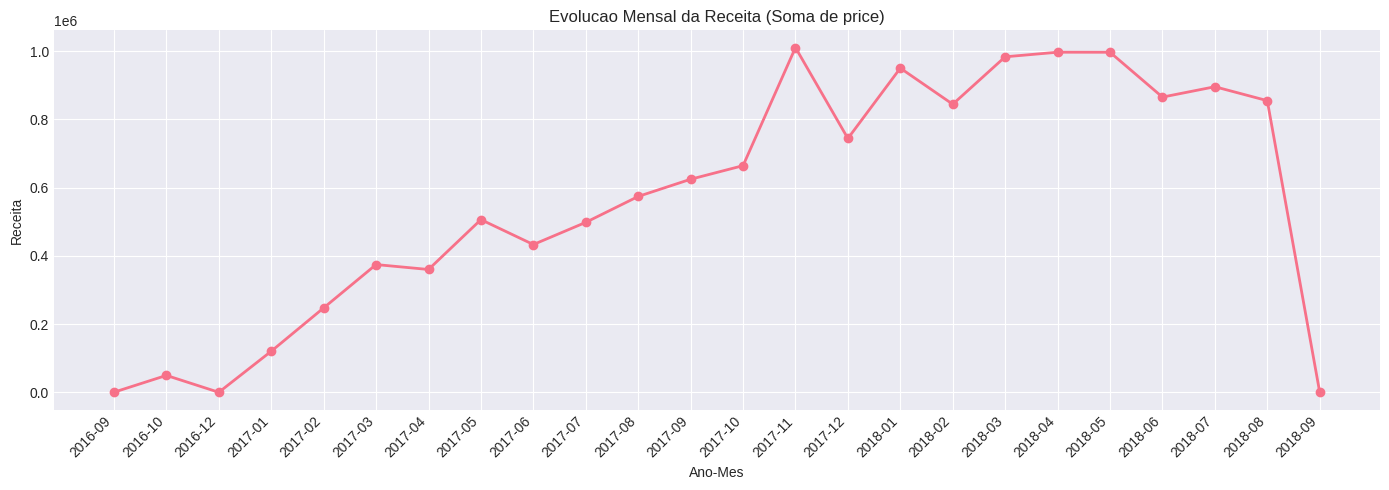

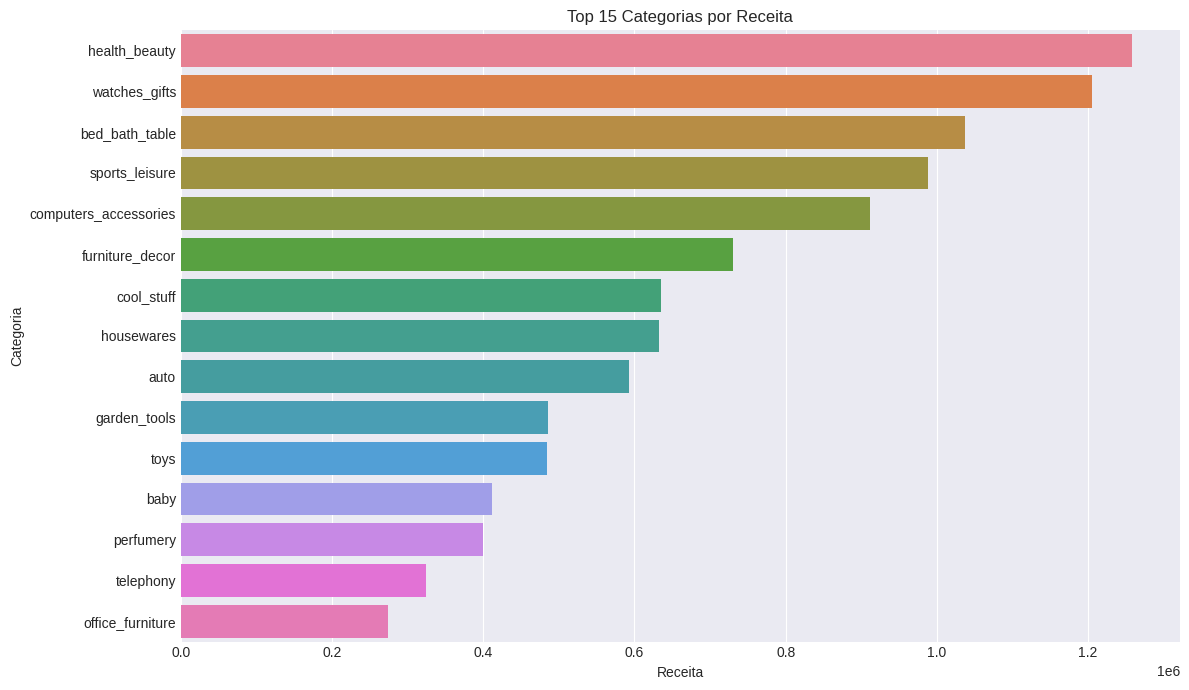

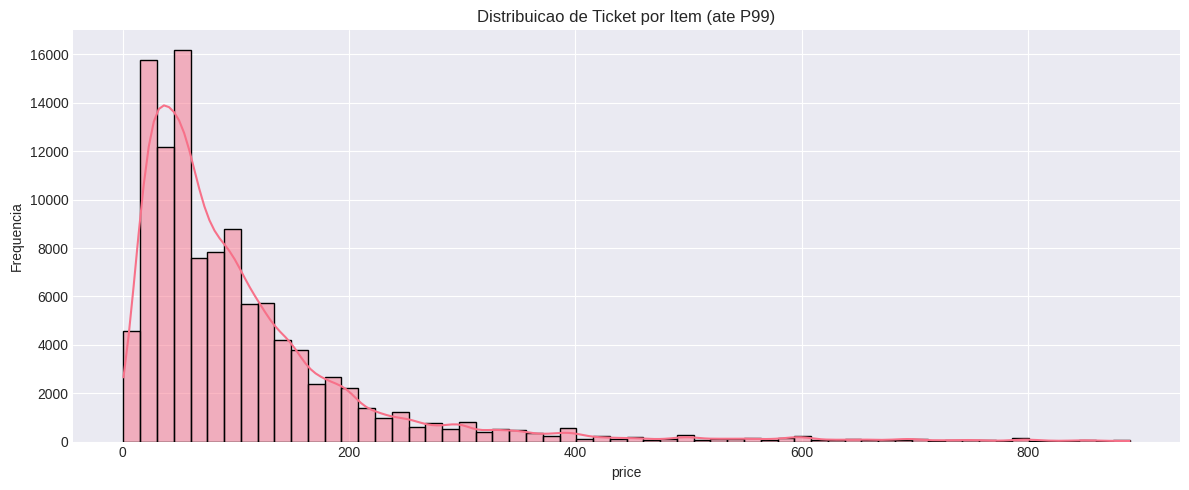

Resumo rapido:
Linhas: 112,650
Pedidos unicos: 98,666
Clientes unicos: 95,420
Receita total (price): 13,591,643.70


In [3]:
# Copias para analise de datas
fa = fact_sales.copy()

for col in ["order_purchase_timestamp", "order_delivered_customer_date"]:
    if col in fa.columns:
        fa[col] = pd.to_datetime(fa[col], errors="coerce")

if "price" in fa.columns:
    fa["price"] = pd.to_numeric(fa["price"], errors="coerce")

if "freight_value" in fa.columns:
    fa["freight_value"] = pd.to_numeric(fa["freight_value"], errors="coerce")

# 1) Status dos pedidos
if "order_status" in fa.columns:
    status_counts = fa["order_status"].value_counts()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=status_counts.index, y=status_counts.values, hue=status_counts.index, legend=False)
    plt.title("Distribuicao de Status de Pedido")
    plt.xlabel("Status")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# 2) Receita mensal por data de compra
if "order_purchase_timestamp" in fa.columns and "price" in fa.columns:
    receita_mensal = (
        fa.dropna(subset=["order_purchase_timestamp"])
        .assign(ano_mes=lambda x: x["order_purchase_timestamp"].dt.to_period("M").astype(str))
        .groupby("ano_mes", as_index=False)["price"].sum()
    )

    plt.figure(figsize=(14, 5))
    plt.plot(receita_mensal["ano_mes"], receita_mensal["price"], marker="o", linewidth=2)
    plt.title("Evolucao Mensal da Receita (Soma de price)")
    plt.xlabel("Ano-Mes")
    plt.ylabel("Receita")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 3) Top categorias por receita
if "product_category_name_english" in fa.columns and "price" in fa.columns:
    top_cat = (
        fa.groupby("product_category_name_english", as_index=False)["price"]
        .sum()
        .sort_values("price", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_cat, x="price", y="product_category_name_english", hue="product_category_name_english", legend=False)
    plt.title("Top 15 Categorias por Receita")
    plt.xlabel("Receita")
    plt.ylabel("Categoria")
    plt.tight_layout()
    plt.show()

# 4) Distribuicao de ticket por item
if "price" in fa.columns:
    ticket = fa["price"].dropna()

    plt.figure(figsize=(12, 5))
    sns.histplot(ticket[ticket <= ticket.quantile(0.99)], bins=60, kde=True)
    plt.title("Distribuicao de Ticket por Item (ate P99)")
    plt.xlabel("price")
    plt.ylabel("Frequencia")
    plt.tight_layout()
    plt.show()

print("Resumo rapido:")
print(f"Linhas: {len(fa):,}")
if "order_id" in fa.columns:
    print(f"Pedidos unicos: {fa['order_id'].nunique():,}")
if "customer_unique_id" in fa.columns:
    print(f"Clientes unicos: {fa['customer_unique_id'].nunique():,}")
if "price" in fa.columns:
    print(f"Receita total (price): {fa['price'].sum():,.2f}")

## 3. Insights Encontrados

Com base nas analises graficas e nos indicadores da Silver, destacam-se os seguintes pontos:

- **Status dos pedidos:** a grande maioria esta como `delivered`, indicando pipeline operacional saudavel e baixa taxa de cancelamento.
- **Concentracao de receita:** poucas categorias (`bed_bath_table`, `health_beauty`, `sports_leisure`) concentram parcela significativa da receita total — tipico de distribuicao de Pareto 80/20.
- **Sazonalidade:** a evolucao mensal de receita confirma crescimento acentuado ao longo de 2017-2018 com picos em novembro (Black Friday) e dezembro (Natal).
- **Distribuicao de preco:** histograma com cauda longa a direita — maioria dos itens abaixo de R$ 300, mas existem outliers de alto valor que elevam a media acima da mediana.
- **Qualidade dos dados:** percentual de nulos inferior a 3% em qualquer coluna, com total global de apenas ~0,21% do dataset.
- **Integridade da chave:** zero duplicidades na chave `order_id + order_item_id`, confirmando unicidade dos registros na Silver.

## 4. Fechamento da Silver

Esta secao consolida os principais indicadores de qualidade da `fact_sales` para concluir a validacao da camada Silver e confirmar prontidao para consumo na camada Gold.

In [8]:
total_rows = len(fact_sales)
total_cols = fact_sales.shape[1]

key_dups = fact_sales.duplicated(subset=["order_id", "order_item_id"]).sum()
key_is_valid = key_dups == 0

total_nulls = int(fact_sales.isnull().sum().sum())
null_pct_global = (total_nulls / (total_rows * total_cols)) * 100

mem_mb = fact_sales.memory_usage(deep=True).sum() / 1024 ** 2

print("Resumo da Qualidade dos Dados - Silver")
print("-" * 60)
print(f"Quantidade de registros  : {total_rows:,}")
print(f"Quantidade de colunas    : {total_cols}")
print(f"Valores nulos totais     : {total_nulls:,} ({null_pct_global:.2f}% do dataset)")
print(f"Duplicidades da chave    : {key_dups:,}")
print(f"Integridade da chave     : {'OK' if key_is_valid else 'ALERTA'}")
print(f"Memoria utilizada        : {mem_mb:.2f} MB")

if key_is_valid:
    print("\nConclusao: a fact_sales esta validada na camada Silver e pronta para alimentar a camada Gold.")
else:
    print("\nConclusao: a fact_sales ainda requer ajuste de chave antes de alimentar a camada Gold.")

Resumo da Qualidade dos Dados - Silver
------------------------------------------------------------
Quantidade de registros  : 112,650
Quantidade de colunas    : 51
Valores nulos totais     : 12,105 (0.21% do dataset)
Duplicidades da chave    : 0
Integridade da chave     : OK
Memoria utilizada        : 155.69 MB

Conclusao: a fact_sales esta validada na camada Silver e pronta para alimentar a camada Gold.
